# Real-Time Driver Drowsiness Detection menggunakan Faster R-CNN
## Dataset: NTHU-DDD Multi-Class (Kaggle)

---

- Benedict Aurelius (2306209095)
- Deandro Najwan Ahmad Syahbanna (2306213174)
- Nelson Laurensius (2306161845)
- Wesley Frederick Oh (2306202763)

## BAGIAN 1: Environment Setup

In [18]:
# ============================================================
# 1.1 Instalasi Library
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())

packages = [
    'torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118',
    'opencv-python-headless',
    'albumentations',
    'kaggle',
    'matplotlib seaborn',
    'tqdm',
    'Pillow',
    'pandas',
    'scikit-learn',
    'pycocotools',
    'torchmetrics',
    'ipywidgets',
    'mediapipe'
]

for pkg in packages:
    try:
        install(pkg)
        print(f'✅ {pkg.split()[0]} installed')
    except Exception as e:
        print(f'⚠️  {pkg.split()[0]}: {e}')

✅ torch installed
✅ opencv-python-headless installed
✅ albumentations installed
✅ kaggle installed
✅ matplotlib installed
✅ tqdm installed
✅ Pillow installed
✅ pandas installed
✅ scikit-learn installed
✅ pycocotools installed
✅ torchmetrics installed
✅ ipywidgets installed
✅ mediapipe installed


In [19]:
# ============================================================
# 1.2 Import Library
# ============================================================
import os, sys, json, time, random, shutil, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter, defaultdict
from copy import deepcopy

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

# OpenCV
import cv2

# Augmentasi
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
from torchmetrics.detection.mean_ap import MeanAveragePrecision

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

# ============================================================
# 1.3 Konfigurasi Device
# ============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')

if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ============================================================
# 1.4 Hyperparameter & Path
# ============================================================
CFG = {
    # Path
    'DATA_ROOT'     : './nthu_ddd',
    'ANNO_DIR'      : './annotations',
    'CHECKPOINT_DIR': './checkpoints',
    'LOG_DIR'       : './logs',

    # Dataset
    'IMG_SIZE'      : 640,
    'TRAIN_RATIO'   : 0.75,
    'VAL_RATIO'     : 0.15,
    'TEST_RATIO'    : 0.10,

    # Training
    'BATCH_SIZE'    : 4,
    'NUM_EPOCHS'    : 20,
    'LR'            : 0.005,
    'MOMENTUM'      : 0.9,
    'WEIGHT_DECAY'  : 5e-4,
    'LR_STEP_SIZE'  : 7,
    'LR_GAMMA'      : 0.1,
    'NUM_WORKERS'   : 2,

    # Model
    'SCORE_THRESH'  : 0.5,
    'NMS_THRESH'    : 0.4,
    'SEED'          : 42,

    # Kelas (0 = background, 1-5 = objek)
    'CLASSES': [
        '__background__',
        'notdrowsy',
        'sleepyCombination',
        'slowBlinkWithNodding',
        'yawning'
    ]
}
CFG['NUM_CLASSES'] = len(CFG['CLASSES'])  # 6 (bg + 5)

# Warna per kelas untuk visualisasi
CLASS_COLORS = {
    'notdrowsy'            : (0,   200,  0),
    'sleepyCombination'    : (255, 200,  0),
    'slowBlinkWithNodding' : (255, 165,  0),
    'yawning'              : (220,  20, 60)
}

# Reproducibility
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['SEED'])

# Buat direktori
for d in [CFG['ANNO_DIR'], CFG['CHECKPOINT_DIR'], CFG['LOG_DIR']]:
    os.makedirs(d, exist_ok=True)

print('\n📁 Konfigurasi siap!')
print(f'   Classes  : {CFG["CLASSES"][1:]}')
print(f'   Num Class: {CFG["NUM_CLASSES"]} (+ background)')

🖥️  Device: cpu

📁 Konfigurasi siap!
   Classes  : ['notdrowsy', 'sleepyCombination', 'slowBlinkWithNodding', 'yawning']
   Num Class: 5 (+ background)


## BAGIAN 2: Data Collection — Download Dataset Kaggle

In [20]:
# ============================================================
# 2.2 Download Dataset
# ============================================================
import subprocess

DATASET_SLUG = 'samymesbah/nthu-dataset-ddd-multi-class'
DOWNLOAD_DIR = './Multi Class/train'

if not os.path.exists(DOWNLOAD_DIR) or len(os.listdir(DOWNLOAD_DIR)) == 0:
    print('📥 Mengunduh dataset...')
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', DATASET_SLUG,
         '--path', DOWNLOAD_DIR, '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('✅ Download berhasil!')
    else:
        print(f'❌ Error: {result.stderr}')
else:
    print('✅ Dataset sudah ada, melewati download.')

# ============================================================
# 2.3 Jelajahi Struktur Dataset
# ============================================================
print('\n📂 Struktur Dataset:')
for root, dirs, files in os.walk(DOWNLOAD_DIR):
    depth = root.replace(DOWNLOAD_DIR, '').count(os.sep)
    indent = '   ' * depth
    folder_name = os.path.basename(root)
    n_files = len(files)
    if depth <= 3:
        print(f'{indent}📁 {folder_name}/  [{n_files} files]')
    if depth == 3 and files:
        sample = files[:2]
        for s in sample:
            print(f'{indent}   └─ {s}')

✅ Dataset sudah ada, melewati download.

📂 Struktur Dataset:
📁 train/  [0 files]
   📁 drowsy/  [0 files]
      📁 sleepyCombination/  [17756 files]
      📁 slowBlinkWithNodding/  [9412 files]
      📁 yawning/  [8862 files]
   📁 notdrowsy/  [30491 files]


In [21]:
# ============================================================
# 2.4 Organisasi & Pemetaan Kelas Dataset
# ============================================================
# Dataset NTHU-DDD multi-class memiliki folder per kondisi.
# Kita mapping folder ke salah satu dari 5 kelas target.

# Mapping nama folder → label kelas
FOLDER_TO_CLASS = {
    'notdrowsy'            : 'notdrowsy',
    'sleepyCombination'    : 'sleepyCombination',
    'slowBlinkWithNodding' : 'slowBlinkWithNodding',
    'yawning'              : 'yawning'
}

# Scan semua gambar & assign label
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}
records = []

for root, dirs, files in os.walk(DOWNLOAD_DIR):
    folder_name = os.path.basename(root)
    label = FOLDER_TO_CLASS.get(folder_name, None)
    if label is None:
        # coba case-insensitive
        for k, v in FOLDER_TO_CLASS.items():
            if k.lower() == folder_name.lower():
                label = v
                break
    if label is None:
        continue
    for fname in files:
        if Path(fname).suffix.lower() in IMG_EXT:
            records.append({
                'image_path': os.path.join(root, fname),
                'label': label,
                'folder': folder_name
            })

df = pd.DataFrame(records)
print(f'📊 Total gambar ditemukan : {len(df)}')
print(f'   Distribusi kelas:')
print(df['label'].value_counts().to_string())

📊 Total gambar ditemukan : 66521
   Distribusi kelas:
label
notdrowsy               30491
sleepyCombination       17756
slowBlinkWithNodding     9412
yawning                  8862


## BAGIAN 3: Data Understanding: Eksplorasi Data

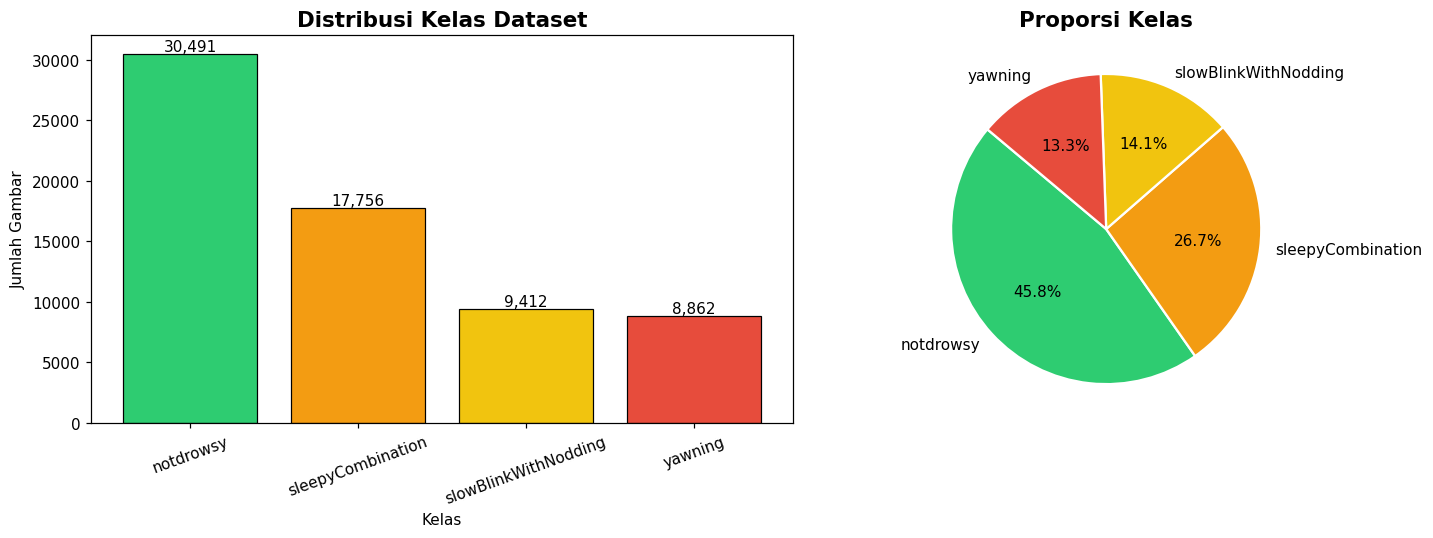


📊 Statistik:
   Total gambar     : 66,521
   Jumlah kelas     : 4
   Kelas terbanyak  : notdrowsy (30,491)
   Kelas tersedikit : yawning (8,862)


In [22]:
# ============================================================
# 3.1 Distribusi Kelas (Bar Chart)
# ============================================================
class_counts = df['label'].value_counts()
colors_bar   = ['#2ecc71','#f39c12','#f1c40f','#e74c3c','#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=colors_bar, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Kelas Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 5,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n📊 Statistik:')
print(f'   Total gambar     : {len(df):,}')
print(f'   Jumlah kelas     : {df["label"].nunique()}')
print(f'   Kelas terbanyak  : {class_counts.idxmax()} ({class_counts.max():,})')
print(f'   Kelas tersedikit : {class_counts.idxmin()} ({class_counts.min():,})')

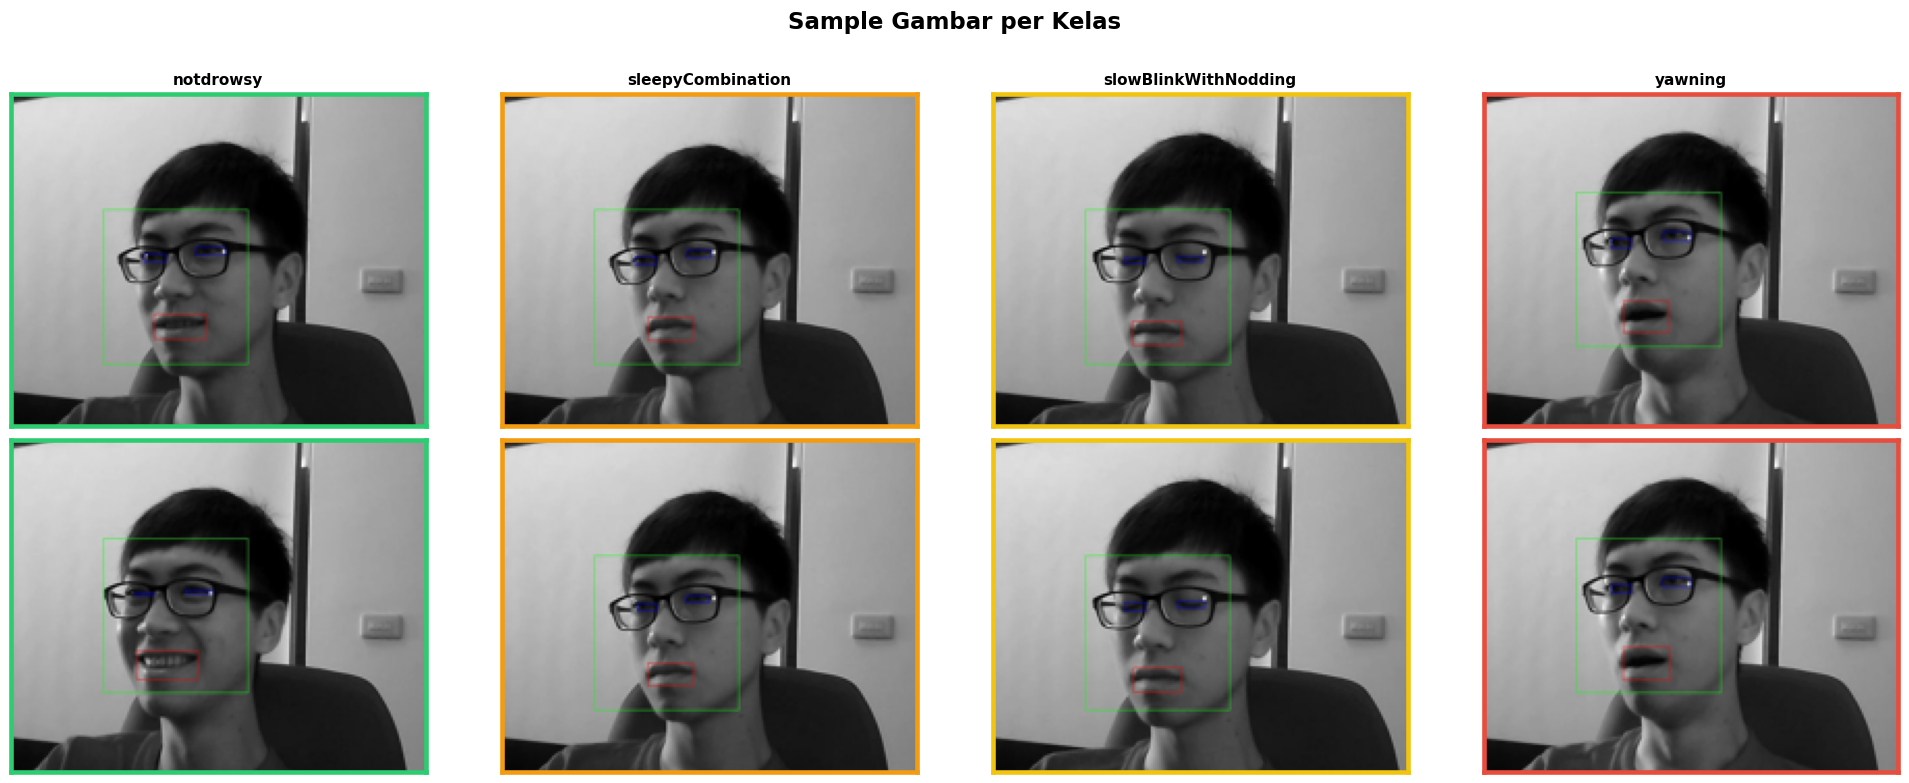

In [23]:
# ============================================================
# 3.2 Visualisasi Sample Gambar per Kelas
# ============================================================
fig, axes = plt.subplots(2, len(CFG['CLASSES'])-1, figsize=(18, 7))
classes = CFG['CLASSES'][1:]  # skip background

for col, cls in enumerate(classes):
    subset = df[df['label'] == cls]['image_path'].values
    for row in range(2):
        ax = axes[row][col]
        if len(subset) > row:
            try:
                img = Image.open(subset[row]).convert('RGB')
                img = img.resize((200, 160))
                ax.imshow(img)
                color = colors_bar[col]
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(3)
            except Exception:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(cls.replace('_','\n'), fontsize=10, fontweight='bold', pad=6)

plt.suptitle('Sample Gambar per Kelas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', bbox_inches='tight', dpi=120)
plt.show()

📐 Menganalisis properti gambar (sample 300)...


Analisis:   0%|          | 0/300 [00:00<?, ?it/s]

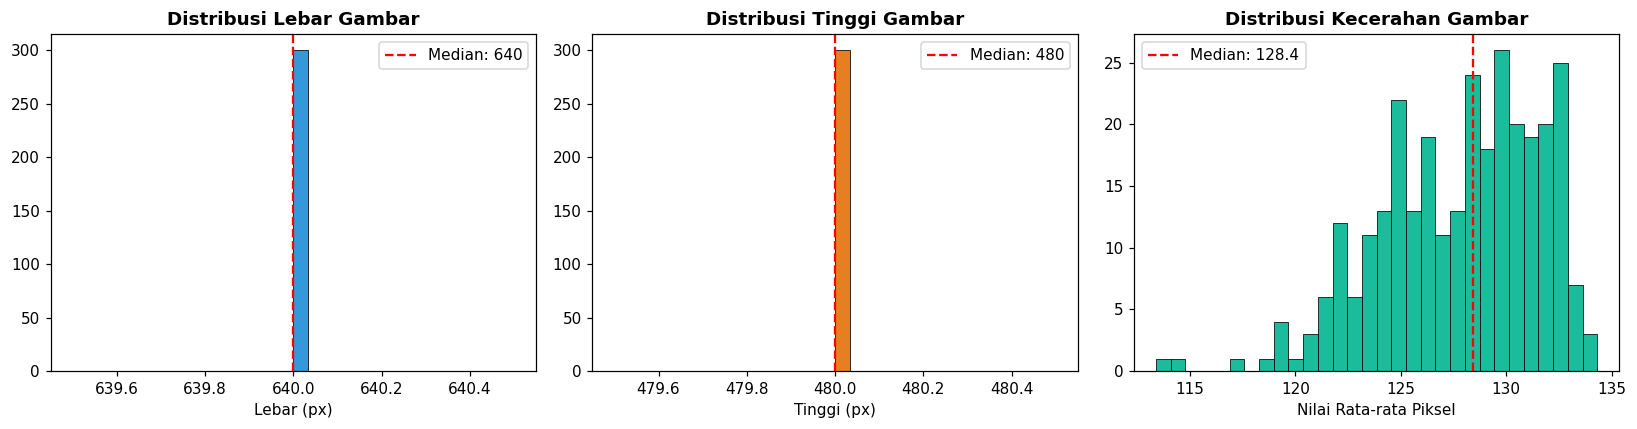


📐 Statistik Gambar:
   Resolusi umum : 640×480 px
   Kecerahan rata: 127.8 / 255


In [24]:
# ============================================================
# 3.3 Analisis Properti Gambar (Resolusi, Brightness)
# ============================================================
print('📐 Menganalisis properti gambar (sample 300)...')
SAMPLE_N = min(300, len(df))
sample_df = df.sample(SAMPLE_N, random_state=CFG['SEED'])

widths, heights, brights = [], [], []
for path in tqdm(sample_df['image_path'], desc='Analisis'):
    try:
        img = np.array(Image.open(path).convert('RGB'))
        widths.append(img.shape[1])
        heights.append(img.shape[0])
        brights.append(img.mean())
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=30, color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribusi Lebar Gambar', fontweight='bold')
axes[0].set_xlabel('Lebar (px)')
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e67e22', edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribusi Tinggi Gambar', fontweight='bold')
axes[1].set_xlabel('Tinggi (px)')
axes[1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.0f}')
axes[1].legend()

axes[2].hist(brights, bins=30, color='#1abc9c', edgecolor='black', linewidth=0.5)
axes[2].set_title('Distribusi Kecerahan Gambar', fontweight='bold')
axes[2].set_xlabel('Nilai Rata-rata Piksel')
axes[2].axvline(np.median(brights), color='red', linestyle='--', label=f'Median: {np.median(brights):.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('image_properties.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n📐 Statistik Gambar:')
print(f'   Resolusi umum : {int(np.median(widths))}×{int(np.median(heights))} px')
print(f'   Kecerahan rata: {np.mean(brights):.1f} / 255')

## BAGIAN 4: Data Preparation

In [26]:
# ============================================================
# 4.1 Generate Bounding Box dengan HSV Masking (Mendeteksi Kotak Hijau)
# ============================================================
import cv2

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CFG['CLASSES'])}

def detect_face_bbox(image_path):
    """
    Deteksi wajah dengan mendeteksi letak kotak hijau dan mengembalikan [x1,y1,x2,y2].
    Jika tidak ditemukan, return bbox seluruh gambar.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None
    h, w = img.shape[:2]
    
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask_green = cv2.inRange(hsv, np.array([40, 150, 150]), np.array([80, 255, 255]))
    contours, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    max_area = 0
    best_box = None
    for cnt in contours:
        cx, cy, cw, ch = cv2.boundingRect(cnt)
        if cw > 20 and ch > 20 and (cw*ch) > max_area:
            max_area = cw*ch
            best_box = [cx, cy, cx+cw, cy+ch]
            
    if best_box is not None:
        return best_box, w, h
    
    # Fallback: bbox seluruh gambar
    return [0, 0, w-1, h-1], w, h


print('🔍 Memulai deteksi wajah untuk generate bounding box...')
print(f'   Total gambar: {len(df):,}')
print('   (Proses ini memakan sedikit waktu karena mendeteksi jutaan piksel)')

annotations = []
skipped = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc='Detecting faces via Green Box'):
    bbox, w, h = detect_face_bbox(row['image_path'])
    if bbox is None:
        skipped += 1
        continue
    annotations.append({
        'image_path': row['image_path'],
        'label'     : row['label'],
        'label_idx' : CLASS_TO_IDX[row['label']],
        'bbox'      : bbox,   # [x1, y1, x2, y2]
        'img_w'     : w,
        'img_h'     : h
    })

anno_df = pd.DataFrame(annotations)
print(f'\n✅ Anotasi selesai!')
print(f'   Berhasil : {len(anno_df):,} gambar')
print(f'   Dilewati : {skipped} gambar (tidak bisa dibaca)')

# Simpan ke disk
anno_df.to_csv(os.path.join(CFG['ANNO_DIR'], 'annotations.csv'), index=False)
print(f'   💾 Disimpan ke {CFG["ANNO_DIR"]}/annotations.csv')


🔍 Memulai deteksi wajah untuk generate bounding box...
   Total gambar: 66,521
   (Proses ini memakan sedikit waktu karena mendeteksi jutaan piksel)


Detecting faces via Green Box:   0%|          | 0/66521 [00:00<?, ?it/s]


✅ Anotasi selesai!
   Berhasil : 66,521 gambar
   Dilewati : 0 gambar (tidak bisa dibaca)
   💾 Disimpan ke ./annotations/annotations.csv


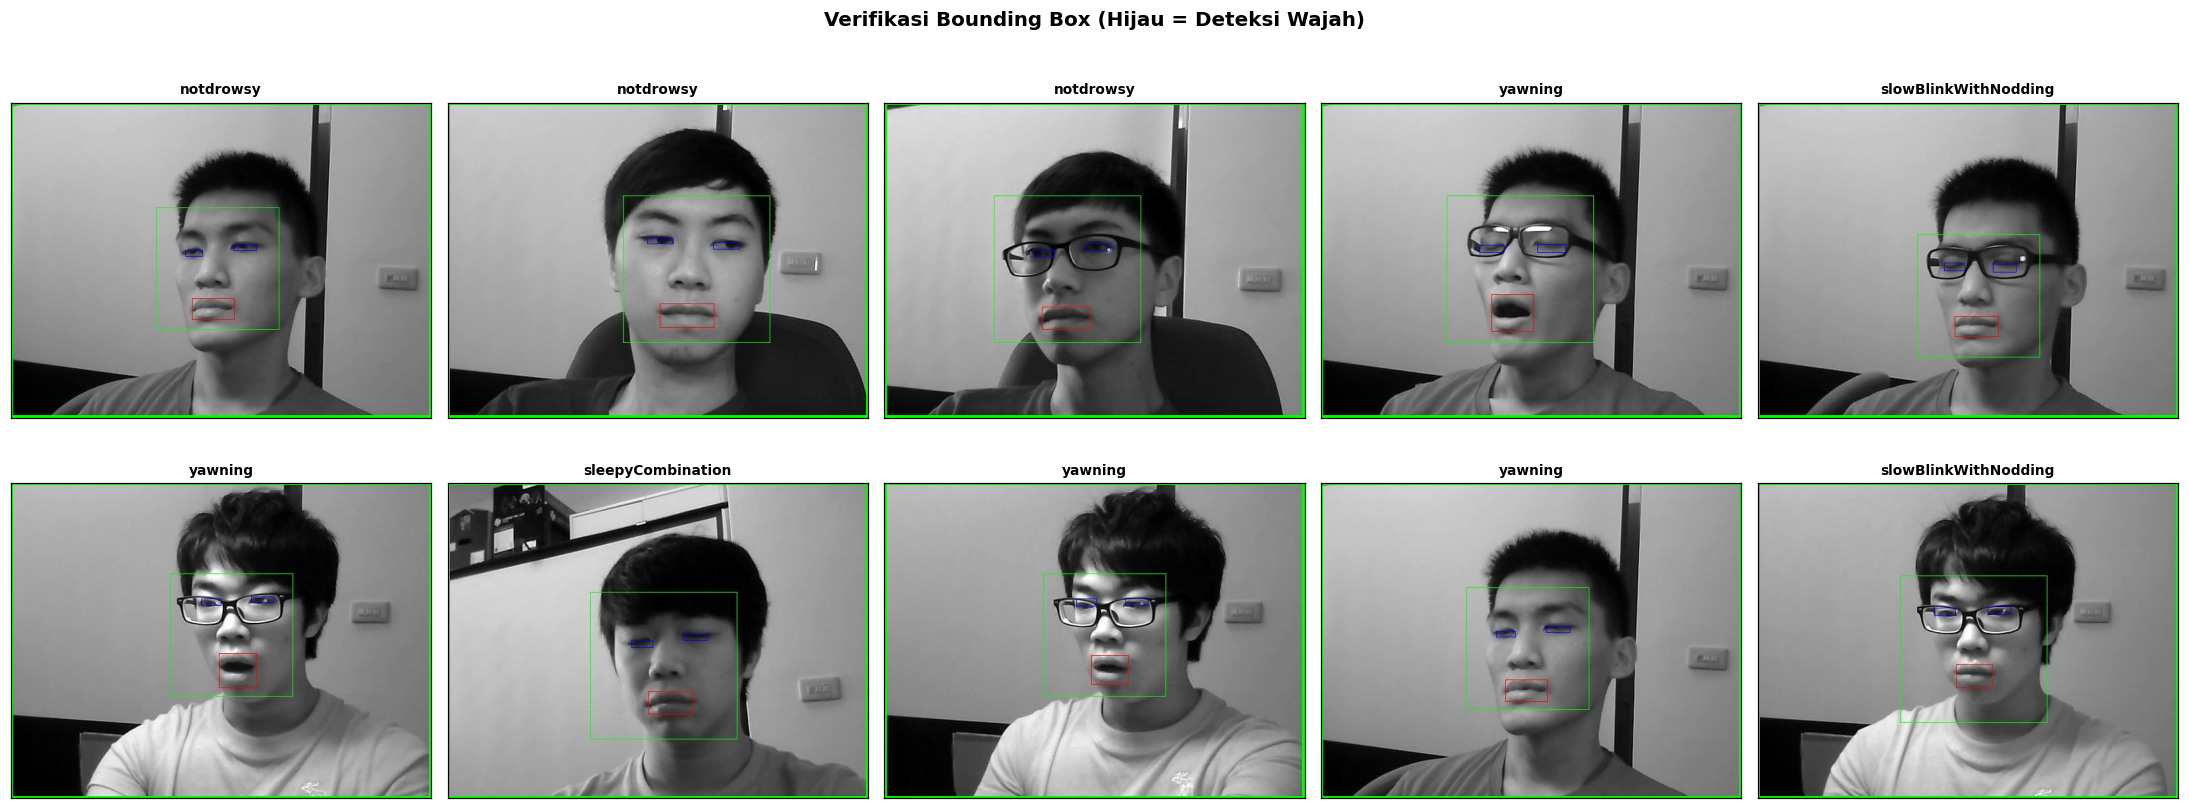

In [27]:
# ============================================================
# 4.2 Verifikasi Bounding Box
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sample_rows = anno_df.sample(10, random_state=CFG['SEED']).reset_index(drop=True)

for i, row in sample_rows.iterrows():
    ax = axes[i // 5][i % 5]
    try:
        img = np.array(Image.open(row['image_path']).convert('RGB'))
        ax.imshow(img)
        x1, y1, x2, y2 = row['bbox']
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.set_title(row['label'].replace('_','\n'), fontsize=9, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Verifikasi Bounding Box (Hijau = Deteksi Wajah)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bbox_verification.png', bbox_inches='tight', dpi=120)
plt.show()

✂️  Split Dataset:
   Train : 49,890 gambar (75.0%)
   Val   : 9,978 gambar (15.0%)
   Test  : 6,653 gambar (10.0%)


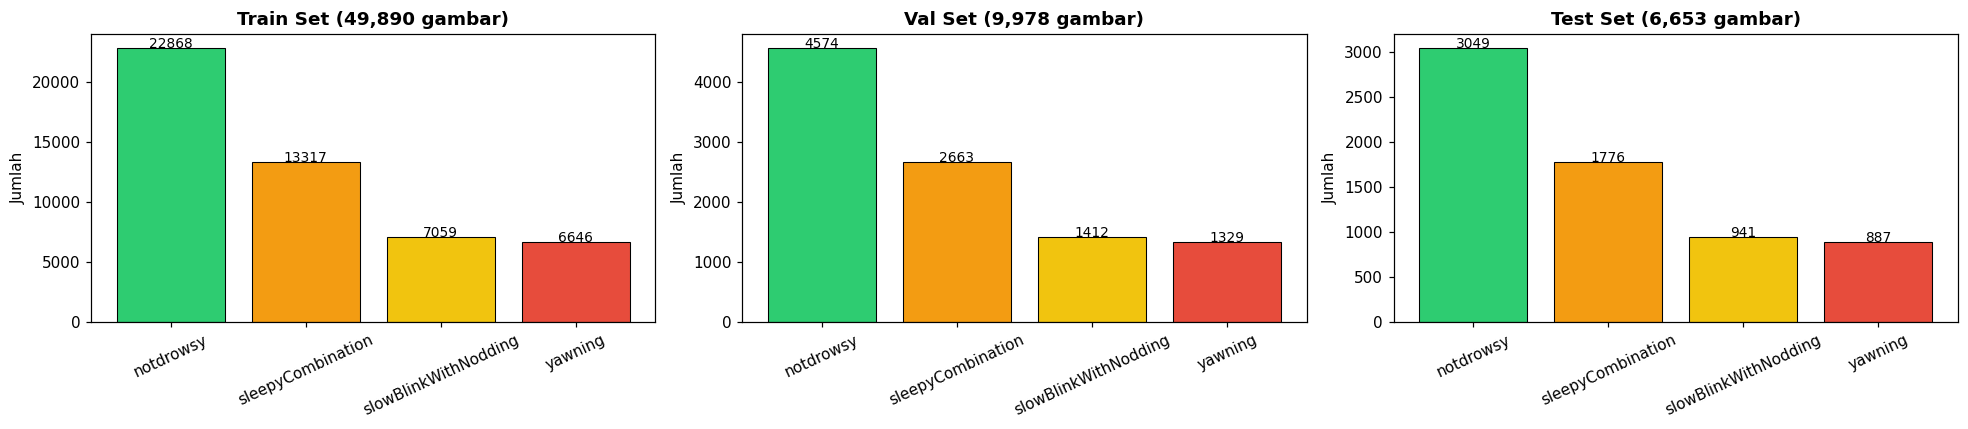

In [28]:
# ============================================================
# 4.3 Stratified Train / Val / Test Split
# ============================================================
from sklearn.model_selection import train_test_split

# Split 75% train, 15% val, 10% test (stratified per kelas)
train_df, temp_df = train_test_split(
    anno_df, test_size=(CFG['VAL_RATIO'] + CFG['TEST_RATIO']),
    stratify=anno_df['label'], random_state=CFG['SEED']
)
val_ratio_adj = CFG['VAL_RATIO'] / (CFG['VAL_RATIO'] + CFG['TEST_RATIO'])
val_df, test_df = train_test_split(
    temp_df, test_size=(1 - val_ratio_adj),
    stratify=temp_df['label'], random_state=CFG['SEED']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('✂️  Split Dataset:')
print(f'   Train : {len(train_df):,} gambar ({len(train_df)/len(anno_df)*100:.1f}%)')
print(f'   Val   : {len(val_df):,} gambar ({len(val_df)/len(anno_df)*100:.1f}%)')
print(f'   Test  : {len(test_df):,} gambar ({len(test_df)/len(anno_df)*100:.1f}%)')

# Visualisasi distribusi per split
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, (name, data) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    vc = data['label'].value_counts()
    ax.bar(vc.index, vc.values, color=colors_bar[:len(vc)], edgecolor='black', linewidth=0.7)
    ax.set_title(f'{name} Set ({len(data):,} gambar)', fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=25)
    for p in ax.patches:
        ax.text(p.get_x()+p.get_width()/2, p.get_height()+2,
                str(int(p.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

In [29]:
# ============================================================
# 4.4 Custom Dataset Class untuk Faster R-CNN
# ============================================================
class DrowsinessDataset(Dataset):
    """
    Dataset untuk Faster R-CNN.
    Output: (image_tensor, target_dict)
    target_dict = {
        'boxes'  : FloatTensor[N,4],   # x1,y1,x2,y2
        'labels' : Int64Tensor[N],     # kelas idx (1-based, 0=bg)
        'image_id': Int64Tensor[1]
    }
    """
    def __init__(self, df, transform=None, img_size=640):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.img_size  = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        
        img_bgr = cv2.imread(row['image_path'])
        
        # 1. HAPUS KOTAK WARNA (Inpainting) AGAR MODEL TIDAK CURANG
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        mask_green = cv2.inRange(hsv, np.array([40, 150, 150]), np.array([80, 255, 255]))
        mask_blue  = cv2.inRange(hsv, np.array([100, 150, 150]), np.array([140, 255, 255]))
        mask_red1  = cv2.inRange(hsv, np.array([0, 150, 150]), np.array([10, 255, 255]))
        mask_red2  = cv2.inRange(hsv, np.array([160, 150, 150]), np.array([179, 255, 255]))
        
        all_colors_mask = mask_green | mask_blue | mask_red1 | mask_red2
        kernel = np.ones((3,3), np.uint8)
        all_colors_mask = cv2.dilate(all_colors_mask, kernel, iterations=1)
        
        img_cleaned = cv2.inpaint(img_bgr, all_colors_mask, 3, cv2.INPAINT_TELEA)
        
        # Convert ke RGB (format standar Albumentations & PyTorch)
        img = cv2.cvtColor(img_cleaned, cv2.COLOR_BGR2RGB)
        
        # Parse bbox dari dataframe
        if isinstance(row['bbox'], str):
            import ast
            bbox = ast.literal_eval(row['bbox'])
        else:
            bbox = row['bbox']
        x1, y1, x2, y2 = bbox
        label_idx = int(row['label_idx'])

        # Albumentations augmentation
        if self.transform:
            transformed = self.transform(
                image=img,
                bboxes=[[x1, y1, x2, y2]],
                labels=[label_idx]
            )
            img = transformed['image']          # sudah tensor HWC→CHW float/uint8
            bboxes = transformed['bboxes']
            labels = transformed['labels']
        else:
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0
            bboxes = [[x1, y1, x2, y2]]
            labels = [label_idx]

        if len(bboxes) == 0:
            # Augmentasi menghilangkan bbox → kembalikan seluruh gambar
            h, w = img.shape[-2], img.shape[-1]
            bboxes = [[0, 0, w, h]]
            labels = [label_idx]

        target = {
            'boxes'   : torch.tensor(bboxes, dtype=torch.float32),
            'labels'  : torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx], dtype=torch.int64)
        }
        return img, target


print('✅ DrowsinessDataset class siap')


✅ DrowsinessDataset class siap


In [ ]:
# ============================================================
# 4.5 Augmentasi Data
# ============================================================
IMG_SIZE = CFG['IMG_SIZE']

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.GaussianBlur(blur_limit=(3,7), p=0.3),
    A.RandomGamma(gamma_limit=(80,120), p=0.3),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.3),  # Penting untuk kondisi siang/malam
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'],
                             min_visibility=0.3))

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'],
                             min_visibility=0.3))

# ============================================================
# 4.6 Buat DataLoader
# ============================================================
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = DrowsinessDataset(train_df, transform=train_transform, img_size=IMG_SIZE)
val_dataset   = DrowsinessDataset(val_df,   transform=val_transform,   img_size=IMG_SIZE)
test_dataset  = DrowsinessDataset(test_df,  transform=val_transform,   img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH_SIZE'],
                          shuffle=True,  num_workers=CFG['NUM_WORKERS'],
                          collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=CFG['NUM_WORKERS'],
                          collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,
                          shuffle=False, num_workers=0,
                          collate_fn=collate_fn)

print('✅ DataLoader siap:')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

# Verifikasi satu batch
imgs, targets = next(iter(train_loader))
print(f'\n🔍 Bentuk satu batch:')
print(f'   Gambar[0] shape: {imgs[0].shape}')
print(f'   BBox[0]        : {targets[0]["boxes"]}')
print(f'   Label[0]       : {targets[0]["labels"]} → {[CFG["CLASSES"][l] for l in targets[0]["labels"].tolist()]}')

✅ DataLoader siap:
   Train batches : 12473
   Val batches   : 2495
   Test batches  : 6653


## BAGIAN 5: Training Model: Faster R-CNN

Menggunakan **Faster R-CNN dengan ResNet-50 + FPN** yang telah di-pretrain pada COCO.
Kita hanya mengganti layer classifier terakhir sesuai jumlah kelas kita.

In [ ]:
# ============================================================
# 5.1 Bangun Model Faster R-CNN
# ============================================================
def build_faster_rcnn(num_classes, score_thresh=0.5):
    """
    Load Faster R-CNN pretrained COCO, ganti head classifier.
    num_classes termasuk background (jadi 6 untuk 5 kelas).
    """
    # Load pretrained weights COCO
    model = fasterrcnn_resnet50_fpn(
        weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )
    
    # Ganti kepala klasifikasi & regresi box
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    # Sesuaikan threshold
    model.roi_heads.score_thresh   = score_thresh
    model.roi_heads.nms_thresh     = CFG['NMS_THRESH']
    model.roi_heads.detections_per_img = 10
    
    return model

model = build_faster_rcnn(CFG['NUM_CLASSES'], CFG['SCORE_THRESH'])
model = model.to(DEVICE)

# Hitung parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'🏗️  Model: Faster R-CNN (ResNet-50 + FPN)')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')
print(f'   Num classes     : {CFG["NUM_CLASSES"]} (bg + {CFG["NUM_CLASSES"]-1} kelas)')

# ============================================================
# 5.2 Optimizer & Scheduler
# ============================================================
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(
    params, lr=CFG['LR'],
    momentum=CFG['MOMENTUM'],
    weight_decay=CFG['WEIGHT_DECAY']
)
lr_scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=CFG['LR_STEP_SIZE'], gamma=CFG['LR_GAMMA']
)

print(f'\n⚙️  Optimizer: SGD (lr={CFG["LR"]}, momentum={CFG["MOMENTUM"]})')
print(f'   Scheduler: StepLR (step={CFG["LR_STEP_SIZE"]}, gamma={CFG["LR_GAMMA"]})')

In [ ]:
# ============================================================
# 5.3 Training Loop
# ============================================================
def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0
    loss_dict_total = defaultdict(float)
    
    pbar = tqdm(loader, desc=f'Epoch {epoch:>2} [Train]', leave=False)
    for images, targets in pbar:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += losses.item()
        for k, v in loss_dict.items():
            loss_dict_total[k] += v.item()
        pbar.set_postfix({'loss': f'{losses.item():.4f}'})
    
    n = len(loader)
    return total_loss / n, {k: v/n for k,v in loss_dict_total.items()}


@torch.no_grad()
def evaluate_epoch(model, loader, device, epoch):
    model.eval()
    metric = MeanAveragePrecision(iou_type='bbox')
    
    pbar = tqdm(loader, desc=f'Epoch {epoch:>2} [Val]  ', leave=False)
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        preds  = model(images)
        
        preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
        metric.update(preds_cpu, targets_cpu)
    
    result = metric.compute()
    return result


# ============================================================
# 5.4 Training Loop Utama
# ============================================================
history = {
    'train_loss': [], 'val_map': [], 'val_map_50': [],
    'lr': [], 'loss_classifier': [], 'loss_box_reg': [],
    'loss_objectness': [], 'loss_rpn_box_reg': []
}

best_map   = 0.0
best_epoch = 0
start_time = time.time()

print('🚀 Memulai Training Faster R-CNN...')
print(f'   Epochs     : {CFG["NUM_EPOCHS"]}')
print(f'   Batch Size : {CFG["BATCH_SIZE"]}')
print(f'   Device     : {DEVICE}')
print('─' * 65)
print(f"{'Epoch':>6} | {'Train Loss':>11} | {'mAP@.5:.95':>11} | {'mAP@.50':>9} | {'LR':>8}")
print('─' * 65)

for epoch in range(1, CFG['NUM_EPOCHS'] + 1):
    # Train
    train_loss, loss_components = train_one_epoch(
        model, train_loader, optimizer, DEVICE, epoch
    )
    # Evaluate
    val_metrics = evaluate_epoch(model, val_loader, DEVICE, epoch)
    lr_scheduler.step()

    current_lr  = optimizer.param_groups[0]['lr']
    val_map     = float(val_metrics['map'])
    val_map50   = float(val_metrics['map_50'])

    # Simpan history
    history['train_loss'].append(train_loss)
    history['val_map'].append(val_map)
    history['val_map_50'].append(val_map50)
    history['lr'].append(current_lr)
    for k in ['loss_classifier','loss_box_reg','loss_objectness','loss_rpn_box_reg']:
        history[k].append(loss_components.get(k, 0.0))

    # Simpan best model
    is_best = val_map > best_map
    if is_best:
        best_map   = val_map
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_map': best_map,
            'cfg': CFG
        }, os.path.join(CFG['CHECKPOINT_DIR'], 'best_model.pth'))

    marker = '★ BEST' if is_best else ''
    print(f'{epoch:>6} | {train_loss:>11.4f} | {val_map:>11.4f} | {val_map50:>9.4f} | {current_lr:>8.6f}  {marker}')

    # Simpan checkpoint setiap 5 epoch
    if epoch % 5 == 0:
        torch.save(model.state_dict(),
                   os.path.join(CFG['CHECKPOINT_DIR'], f'epoch_{epoch:03d}.pth'))

elapsed = time.time() - start_time
print('─' * 65)
print(f'✅ Training selesai dalam {elapsed/60:.1f} menit')
print(f'   Best mAP@.5:.95 = {best_map:.4f} (epoch {best_epoch})')

# Simpan history
with open(os.path.join(CFG['LOG_DIR'], 'history.json'), 'w') as f:
    json.dump(history, f)